# Housing Prices Dataset

## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2 — Data Cleaning

In [5]:
df['mainroad'] = df['mainroad'].map({'yes': 1, 'no': 0})
df['guestroom'] = df['guestroom'].map({'yes': 1, 'no': 0})
df['basement'] = df['basement'].map({'yes': 1, 'no': 0})
df['hotwaterheating'] = df['hotwaterheating'].map({'yes': 1, 'no': 0})
df['airconditioning'] = df['airconditioning'].map({'yes': 1, 'no': 0})
df['prefarea'] = df['prefarea'].map({'yes': 1, 'no': 0})
df['furnishingstatus'] = df['furnishingstatus'].map({'semi-furnished':2, 'furnished': 1, 'unfurnished': 0})

In [6]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,2
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,2
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,1
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0


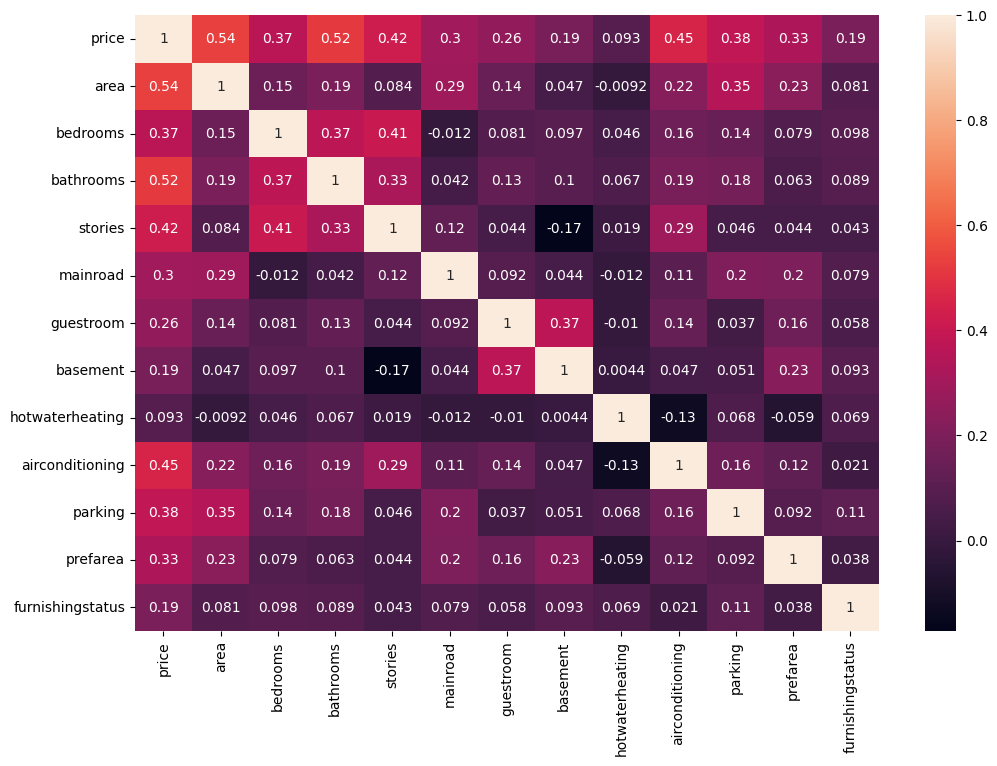

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### Main features that contribute to the price are area, bathrooms, airconditioning, stories, parking, bedrooms etc.  
### Hotwaterheating seems to affect it the least. Therefore, we can remove Hotwaterheating.

In [8]:
data = df.drop(columns=['hotwaterheating'])

In [9]:
y = data['price']
X = data.drop(columns=['price'])

## Task 3 — Model Building

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred_1 = model_1.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_1)))
print("R²:", r2_score(y_test, y_pred_1))

MAE: 981365.2051802555
RMSE: 1344834.4955297157
R²: 0.6421892006211227


In [14]:
from sklearn.ensemble import RandomForestRegressor

model_2 = RandomForestRegressor(random_state=42)
model_2.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
y_pred_2= model_2.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_2)))
print("R²:", r2_score(y_test, y_pred_2))

MAE: 1047955.1782874619
RMSE: 1423956.538340292
R²: 0.598847750796941


## Task 4 - Visualization

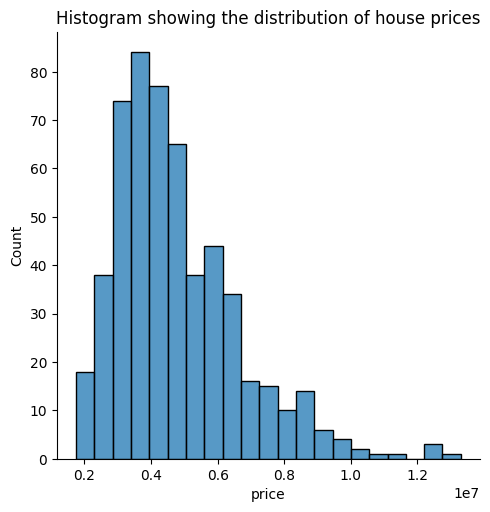

In [24]:
x=data['price']
sns.displot(data, x=x)
plt.title("Histogram showing the distribution of house prices")
plt.show()

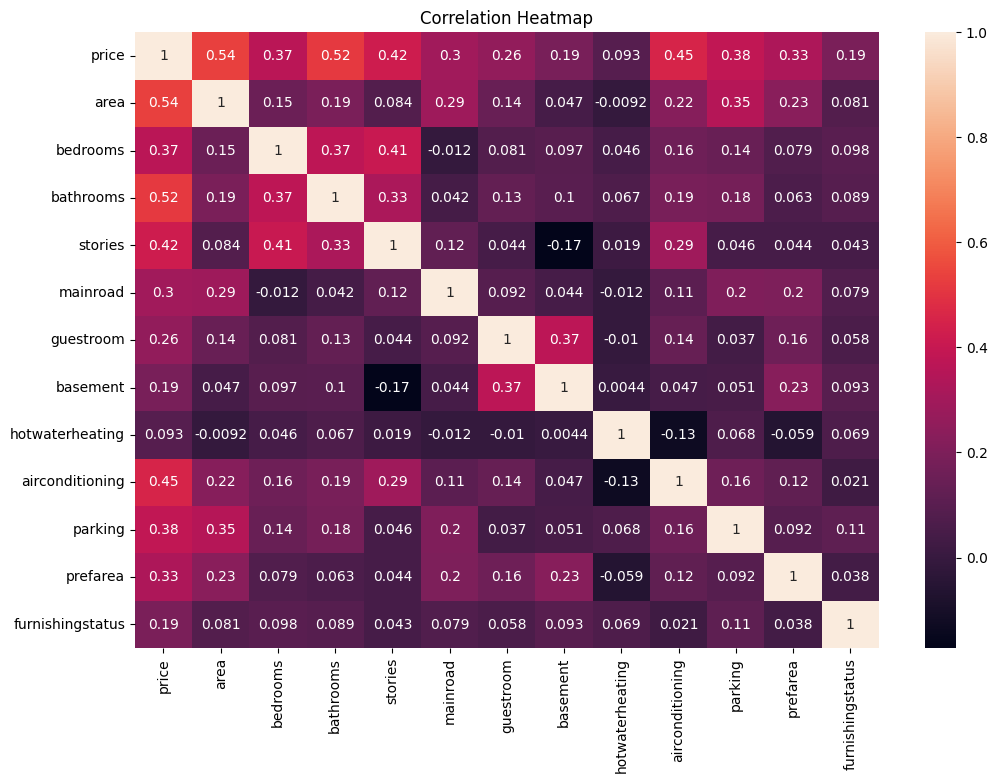

In [18]:
plt.figure(figsize=(12, 8))
plt.title("Correlation Heatmap")
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

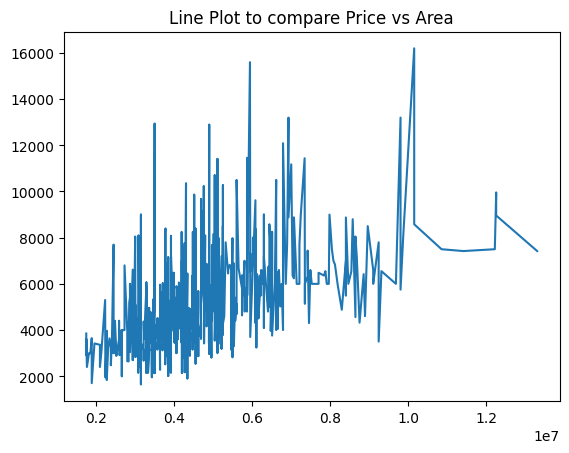

In [30]:
x=data['price']
y=data['area']
plt.title("Line Plot to compare Price vs Area")
plt.plot(x,y)
plt.show()

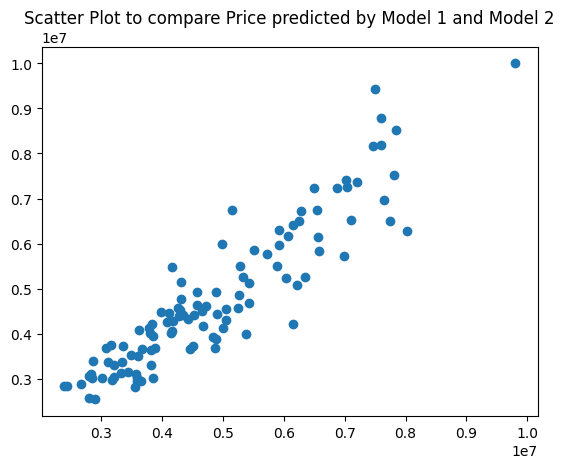

In [33]:
x=y_pred_1
y=y_pred_2
plt.title("Scatter Plot to compare Price predicted by Model 1 and Model 2")
plt.scatter(x,y)
plt.show()

## Task 5 - — Insights & Summary

#### Which features influence house price the most?
>Main features that contribute to the price are
>1. area
2. bathrooms
3. airconditioning
4. stories
5. parking
6. bedrooms

#### How accurate was your model (in plain terms)?
>The Linear Regression model had 0.6421 R<sup>2</sup> Score, meaning it explained around 64% variation in the data.  
>The Random Forest Regressor model has lower R<sup>2</sup> Score than Linear Regression model - 0.5988, meaning it explained around 59% variation in the data.  
>In plain terms, the Linear Regression model has better accuracy than Random Forest Regressor and predicted the house prices fairly close to the actual value. However, 36% of the variation couldn't be explained by existing features, leaving a major scope for improvement.  

#### What surprised you in the data?
>It was surprising that the number of bathrooms had a stronger relationship with house prices than the number of bedrooms. I expected bedrooms to be among the top factors affecting price, but bathrooms showed a higher correlation with house prices.
 
#### One recommendation for a real estate business based on your findings
>From my observations, features like bathrooms, airconditioning, stories, parking affect the prices even more than bedrooms. So, real estate businesses should focus on these features and their development, availability, quality/quantity significantly.